## 1. CART for Classification

In this problem, you will construct and evaluate a CART classification tree to predict CHD using the same dataset. Recall that in this dataset, each row corresponds to a patient in the Framingham Heart Study. The dependent variable of interest is `TenYearCHD`, which is 1 if the patient got CHD in 10 years, and 0 otherwise. The independent variables consist of demographic, medical and lifestyle characteristics of the individual, including age, education, cigarettes per day, blood pressure, bmi...etc.

### Setup & Imports

First, we'll import all the necessary Python libraries.

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, make_scorer
import seaborn as sns
import matplotlib.pyplot as plt

# Set the default theme for seaborn plots
sns.set_theme()

### Reading in the Data

We read in the data. Here, `TenYearCHD` is the dependent variable (target). We'll split the data 70/30, using `stratify` to maintain the class distribution.

In [46]:
framingham = pd.read_csv('framingham.csv')

# Split the data into features (X) and target (y) first
X = framingham.drop(columns='TenYearCHD')
y = framingham['TenYearCHD']

# We use test_size=0.3
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2025, stratify=y
)

# sklearn's DecisionTreeClassifier requires categorical features to be one-hot encoded.

# Identify categorical columns (object or category)
cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()

# One-hot encode
X_train = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=True)

# Align columns - this ensures test set has same columns as train set
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train.sort_index().head()

C:\Users\PSUN\AppData\Local\Temp\ipykernel_44384\1773743446.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()


,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,education_High school/GED,education_Some college/vocational school,education_Some high school
0,1,39,0,0,0,0,0,0,195,106.0,70.0,26.97,80,77,False,False,False
1,0,46,0,0,0,0,0,0,250,121.0,81.0,28.73,95,76,True,False,False
3,0,61,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,False,True,False
5,0,43,0,0,0,0,1,0,228,180.0,110.0,30.30,77,99,True,False,False
7,0,45,1,20,0,0,0,0,313,100.0,71.0,21.68,79,78,True,False,False


### (a): CART with No Loss Matrix

Let's start by training a simple CART model with a `ccp_alpha` value of $0.0035$ and not specifying a loss matrix. If we do not specify a loss matrix, CART will treat false positives and false negatives equally. Note that throughout this problem, we will say that predicting 1 is positive and 0 is negative.

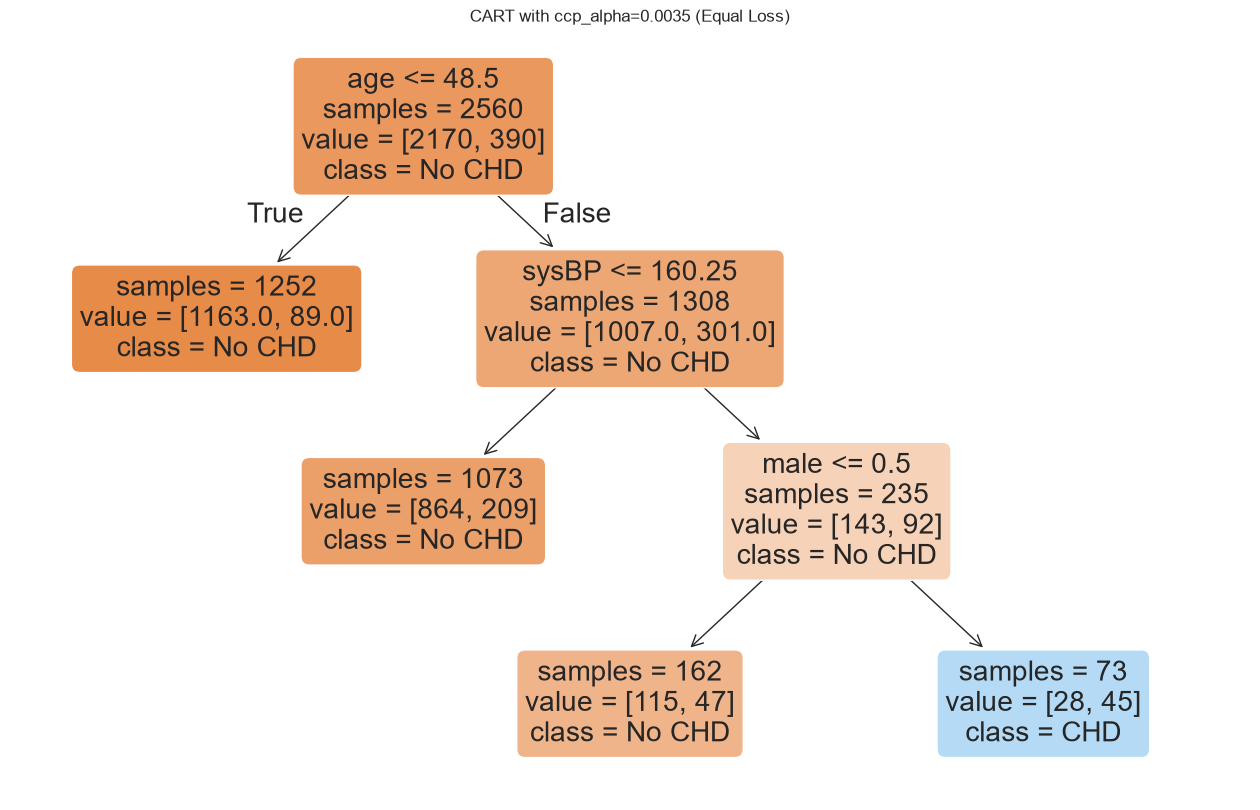

In [47]:
cart_equal_loss = DecisionTreeClassifier(ccp_alpha=0.0035)
cart_equal_loss.fit(X_train, y_train)

# We use plot_tree from sklearn
plt.figure(figsize=(16, 10))
plot_tree(
    cart_equal_loss,
    feature_names=list(X_train.columns),
    class_names=["No CHD", "CHD"],
    impurity=False,
    filled=True,
    rounded=True,
    fontsize=20
)
plt.title("CART with ccp_alpha=0.0035 (Equal Loss)")
plt.show()

**Question 1.** Provide an interpretation of the tree above. Under what conditions does the tree predict that a patient will develop CHD in 10 years?

**Answer 1.** The tree predicts a patient to develop CHD in ten years if and only if they are Male, have `sysBP` higher than $160.25$ and are at least $48.5$ years old.

Now, let's visualize the tree in a bit more detail. We'll use `proportion=True` to show the percentage of samples in each class at the node.

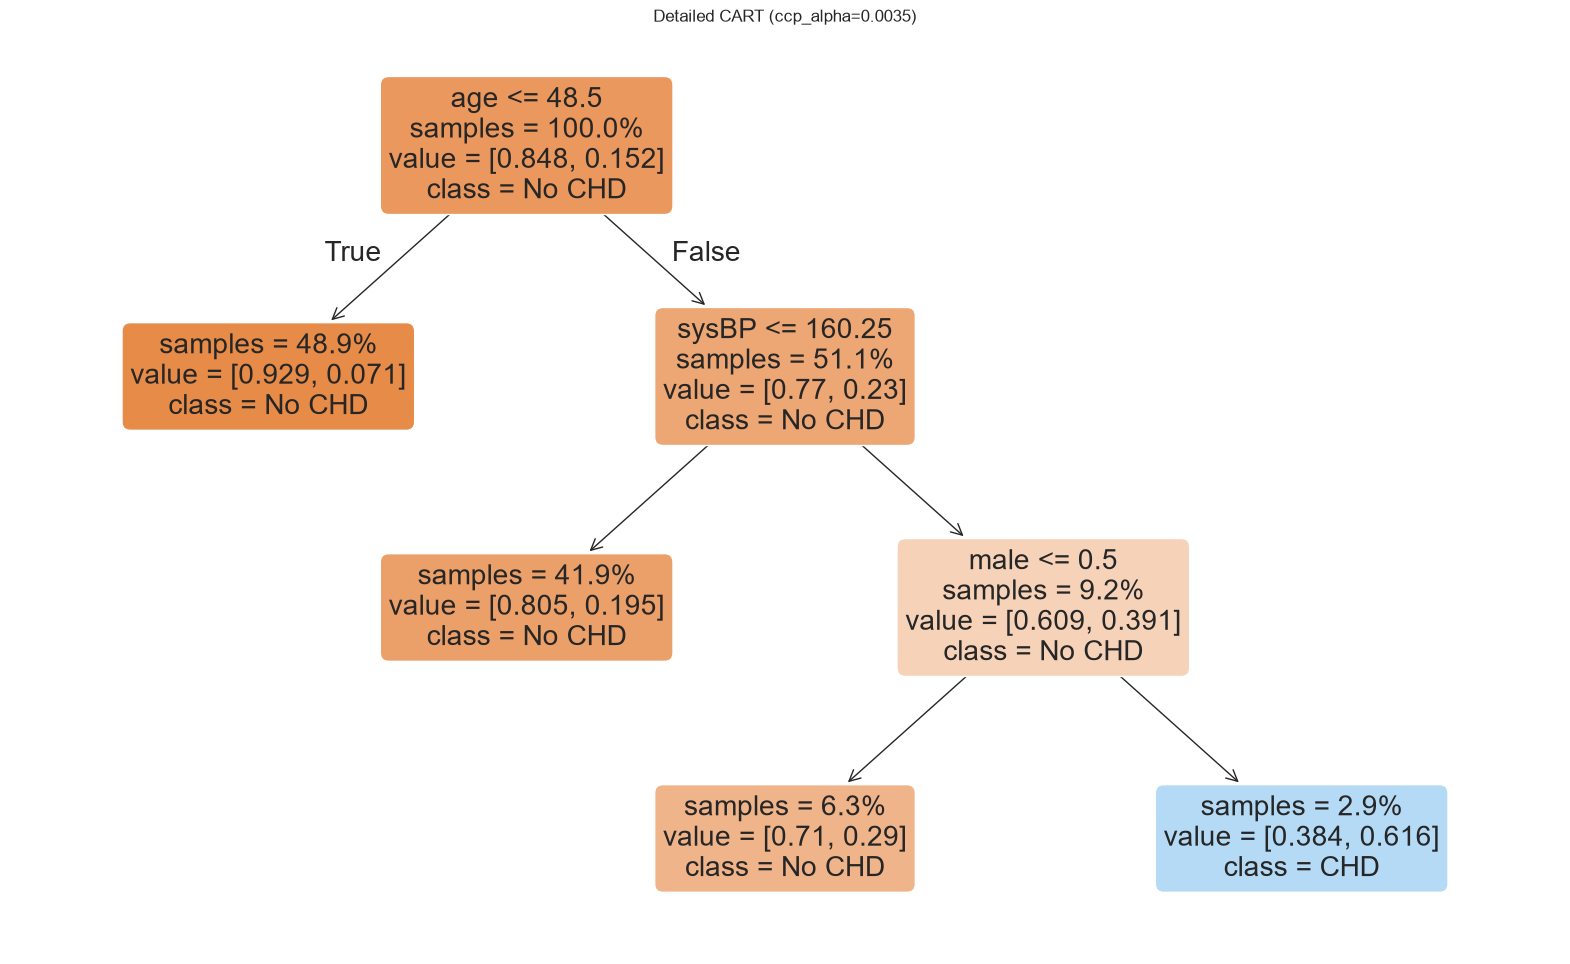

In [48]:
plt.figure(figsize=(20, 12))
plot_tree(
    cart_equal_loss,
    feature_names=list(X_train.columns),
    class_names=["No CHD", "CHD"],
    impurity=False,
    filled=True,
    rounded=True,
    proportion=True,  # Shows proportions instead of counts
    fontsize = 20
)
plt.title("Detailed CART (ccp_alpha=0.0035)")
plt.show()

In the plot above:
* `samples = ...` shows the percentage of the *total* training data in that node.
* `value = [X, Y]` shows the *proportion* of training samples in that node belonging to "No CHD" (X) and "CHD" (Y).
* `class = ...` shows the majority class prediction for that node.

**Example.** For example consider the leftmost leaf node in the plot (`age` $\leq 48.5$). This leaf node contains $48.9 \%$ of all patients (`samples` = $48.9\%$) and the `value` array `[0.929, 0.071]` tells us that $7\%$ of patients in this node develop CHD.

Have a look at the recitation for a more detailed description of the values shown on `sklearn`'s `DecisionTreeClassifier` tree!

**Question 2**. Which leaf node above has the highest proportion of patients with CHD? What percentage of patients in the training dataset does this model predict will develop CHD?

**Answer 2.** The rightmost leaf node has the highest proportion of patients with CHD. It predicts that $2.9\%$ of patients in the traing dataset wil develop CHD.

### (b) Adding in a Loss Matrix

Incorrectly classifying a person who gets CHD (False Negatives, class 1) is more costly. We'll set the cost of FNs as 5 and FPs as 1.

In `sklearn`, we do this using the `class_weight` parameter: `class_weight={0: 1, 1: 5}`.

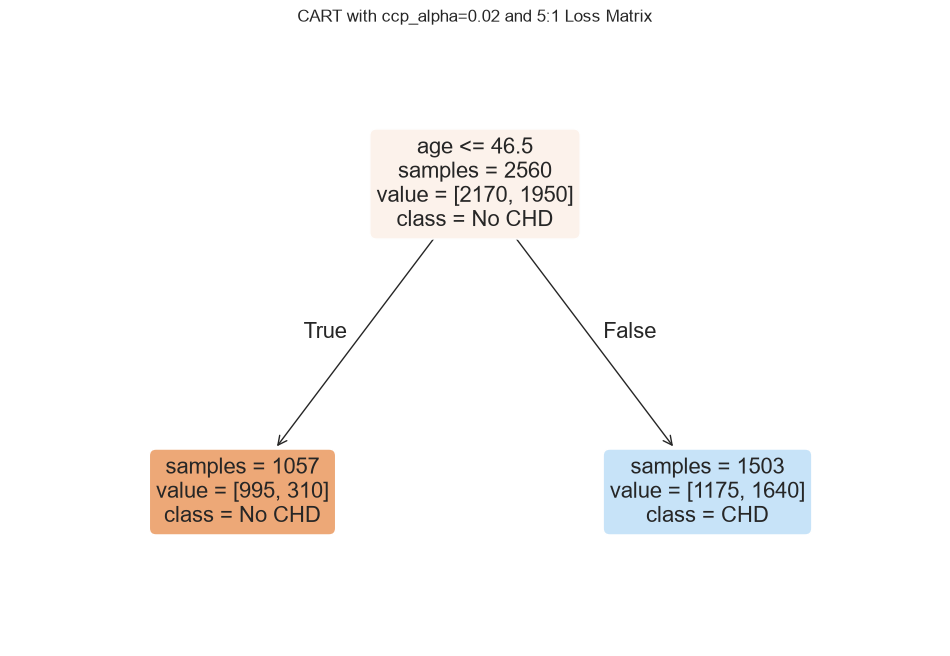

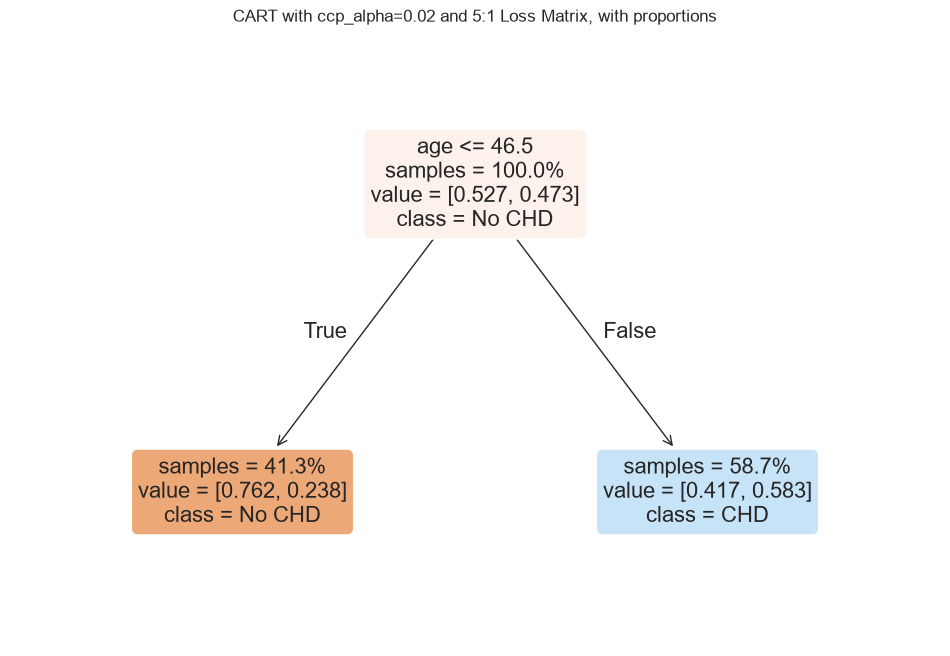

In [49]:
loss_weights = {0: 1, 1: 5}

cart_with_loss = DecisionTreeClassifier(
    ccp_alpha=0.02,
    class_weight=loss_weights,
    random_state=42
)
cart_with_loss.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(
    cart_with_loss,
    feature_names=list(X_train.columns),
    class_names=["No CHD", "CHD"],
    impurity=False,
    filled=True,
    rounded=True,
    fontsize=16
)

plt.title("CART with ccp_alpha=0.02 and 5:1 Loss Matrix")
plt.show()

plt.figure(figsize=(12, 8))
plot_tree(
    cart_with_loss,
    feature_names=list(X_train.columns),
    class_names=["No CHD", "CHD"],
    impurity=False,
    filled=True,
    rounded=True,
    fontsize=16,
    proportion=True
)
plt.title("CART with ccp_alpha=0.02 and 5:1 Loss Matrix, with proportions")
plt.show()

**Question 3.** What percent of all patients in the training set does `cart_with_loss` predict will develop CHD? Between `cart_with_loss` and `cart_equal_loss`, which one do you expect will have a higher false positive rate on the testing dataset? Why?

**Answer 3.** The training samples that `cart_with_loss` predicts will develop CHD are the one in the right node. This contains
$$
1503 \text{ samples,}
$$
while the total number of samples (root) is:
$$
2560 \text{ samples.}
$$
Therefore, the percentage of patients in the training set that `cart_with_loss` predicts will develop CHD is:
$$
\frac{1503}{2560} = 58.7\%.
$$
This percentage can be directly seen on the tree when `proportion` is set to `True` (second tree above). We expect `cart_with_loss` to have a higher false positive rate on the testing data, since the loss matrix incorporates the information that false negatives are more costly than false positives.

### (c) Cross Validation to Optimize `ccp_alpha`

We continue to use the 5:1 cost. We'll run a 10-fold cross-validation to find the best `ccp_alpha`.

We will use `DecisionTreeClassifier(class_weight=loss_weights)` as our base estimator and optimize for 'Accuracy' in `GridSearchCV`.

In [50]:
LossMatrix = np.array([[0, 1],
                       [5, 0]])

def calculate_loss(cm, loss_matrix):
    total_loss = float((cm * loss_matrix).sum())
    n = int(cm.sum())
    return total_loss / n

def raw_avg_loss(y_true, y_pred, loss_matrix=LossMatrix):
    cm = confusion_matrix(y_true, y_pred)
    total_loss = calculate_loss(cm, loss_matrix)
    return total_loss

def custom_avg_loss_scorer():
    """Returns a make_scorer object for GridSearchCV using the raw_avg_loss function."""
    return make_scorer(lambda y_true, y_pred: raw_avg_loss(y_true, y_pred), greater_is_better=False)

loss_scorer = custom_avg_loss_scorer()

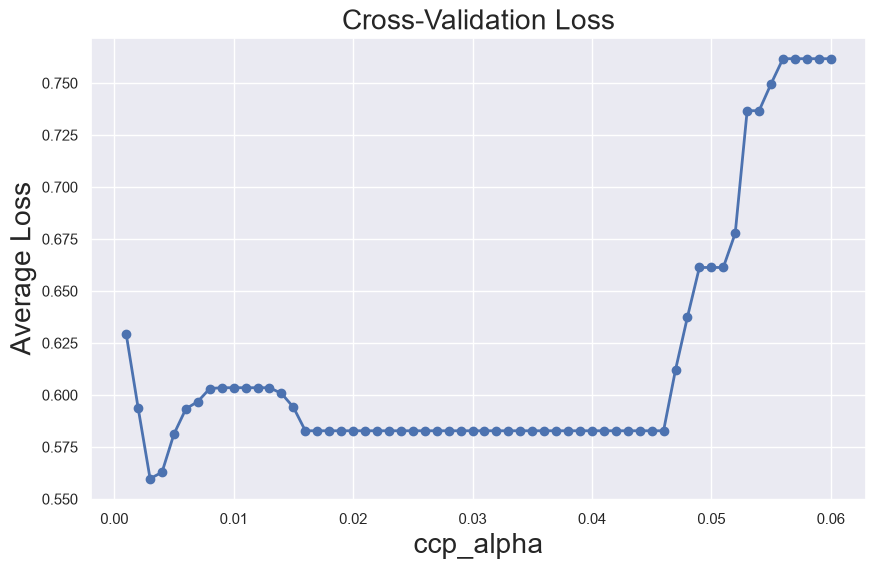

0     0.001
1     0.002
2     0.003
3     0.004
4     0.005
5     0.006
6     0.007
7     0.008
8     0.009
9     0.010
10    0.011
11    0.012
12    0.013
13    0.014
14    0.015
15    0.016
16    0.017
17    0.018
18    0.019
19    0.020
20    0.021
21    0.022
22    0.023
23    0.024
24    0.025
25    0.026
26    0.027
27    0.028
28    0.029
29    0.030
30    0.031
31    0.032
32    0.033
33    0.034
34    0.035
35    0.036
36    0.037
37    0.038
38    0.039
39    0.040
40    0.041
41    0.042
42    0.043
43    0.044
44    0.045
45    0.046
46    0.047
47    0.048
48    0.049
49    0.050
50    0.051
51    0.052
52    0.053
53    0.054
54    0.055
55    0.056
56    0.057
57    0.058
58    0.059
59    0.060
Name: ccp_alpha, dtype: float64


In [51]:
loss_weights = {0: 1, 1: 5}

# Using your specified range for ccp_alpha
cp_vals = np.arange(0.001, 0.0601, 0.001)
param_grid = {'ccp_alpha': cp_vals}

# Base estimator with class_weight
dt_cv = DecisionTreeClassifier(class_weight=loss_weights, random_state=42)

grid = GridSearchCV(
    dt_cv,
    param_grid,
    cv=StratifiedKFold(10, shuffle=True, random_state=2026),
    scoring=loss_scorer, 
    n_jobs=-1
)
grid.fit(X_train, y_train)
# HINT: Use the custom 'loss_scorer'

# 4. Extract results
# mean_test_score is the average *negative* loss
neg_loss_values = grid.cv_results_['mean_test_score']
avg_loss_values = -neg_loss_values # Negate it back to get positive loss
cp_values = grid.cv_results_['param_ccp_alpha'].data.astype(float)

# 5. Store results
cv_results = pd.DataFrame({
    'ccp_alpha': cp_values,
    'AvgLoss': avg_loss_values
})

# 6. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(cv_results['ccp_alpha'], cv_results['AvgLoss'], linewidth=2, marker='o')
plt.xlabel("ccp_alpha", fontsize=20)
plt.ylabel("Average Loss", fontsize=20)
plt.title("Cross-Validation Loss", fontsize=20)
plt.show()

# Print the cp values
print(cv_results['ccp_alpha'])

**Question 4.** Comment on the graph above. Is this what you expected to see? What is the best value of `ccp_alpha`? Is it guaranteed that this value of `ccp_alpha` will achieve the best accuracy on the testing data?

**Answer 4.** The best value of `ccp_alpha` apeares to be 0.003 It is not guaranteed that this value of `ccp_alpha` will achieve the best accuracy on the test data, but the cross-validation procedure provides a good estimate.

**Question 5.** What would be the pros and cons of running 100-fold cross validation instead of 10-fold cross validation? Explain your reasoning.

**Answer 5.** Pros: we may be able to obtain a better estimate of test error for each value of `ccp_alpha`. Cons: this will take much longer to run. We may not have enough data in each validation set if we do a 100 fold cv.

### (d) Best Tree and Performance Comparison

Let's visualize the best tree. We'll take the optimal `ccp_alpha` from our `GridSearchCV` and train a new model.

Best ccp_alpha found: 0.003


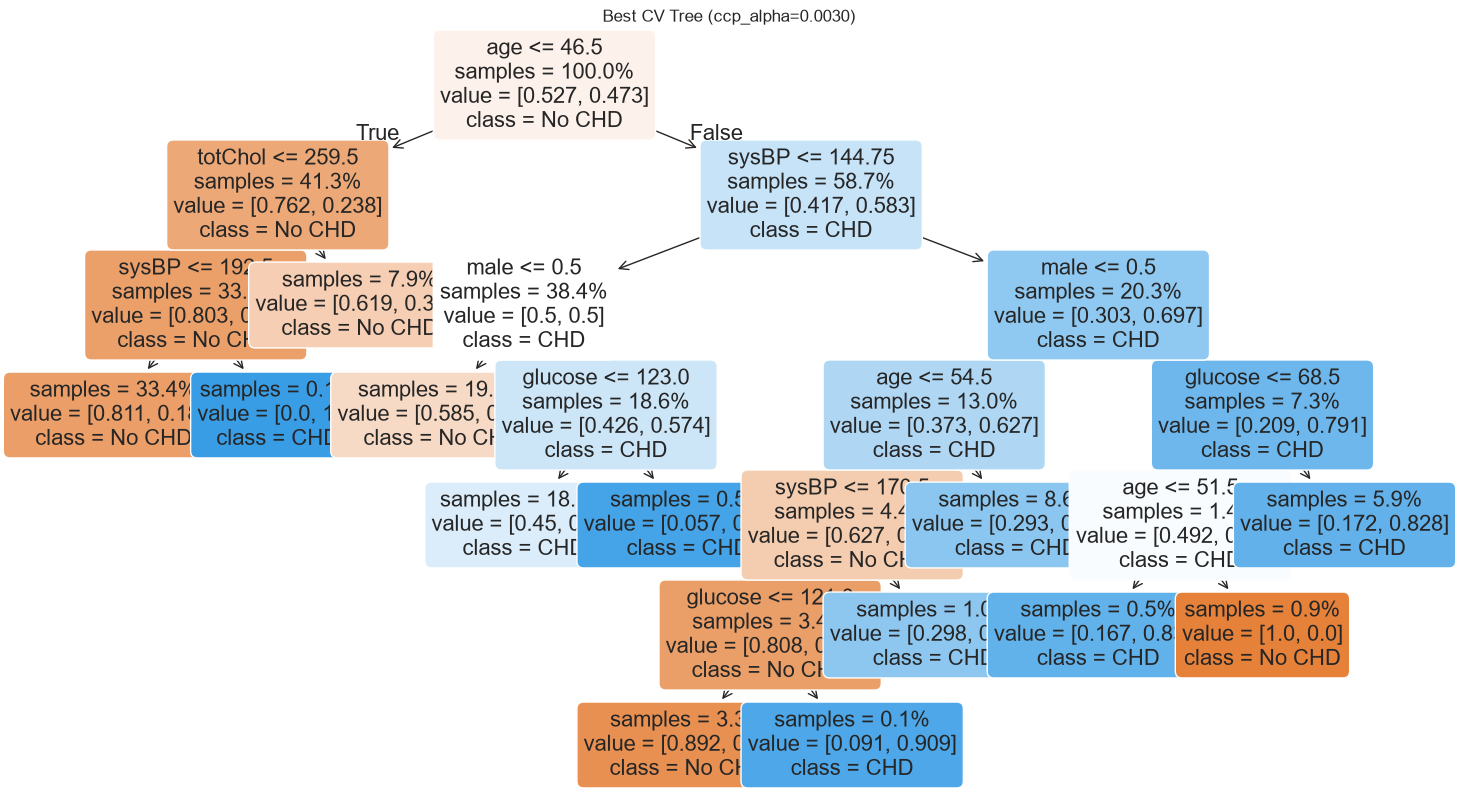

In [52]:
# We get the best_cp from the grid search
best_cp = grid.best_params_['ccp_alpha']
print(f"Best ccp_alpha found: {best_cp}")

best_tree = DecisionTreeClassifier(ccp_alpha=best_cp, class_weight=loss_weights)
best_tree.fit(X_train, y_train)

plt.figure(figsize=(18, 10))
plot_tree(
    best_tree,
    feature_names=list(X_train.columns),
    class_names=["No CHD", "CHD"],
    impurity=False,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=16
)
plt.title(f"Best CV Tree (ccp_alpha={best_cp:.4f})")
plt.show()

**Probabilities with CART.** CART can also provide probabilities. For all patients in a leaf node, CART predicts a probability equal to the *proportion of patients* in that leaf node with CHD.

In [53]:
# .predict_proba() returns probabilities for [class 0, class 1]
# We select the probabilities for class 1 with [:, 1]
cart_probs = best_tree.predict_proba(X_test)[:, 1]

print("CART Probabilities (first 5):")
print(cart_probs[:5])

CART Probabilities (first 5):
[0.82774049 0.70726916 0.55018138 0.41501976 0.82774049]


Let's compare this to a Logistic Regression's probabilities.

In [54]:
# statsmodels requires an explicit constant (intercept) to be added
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test, has_constant='add') # Add constant to test data too

# Fit the Logit model
# We use y_train.values to avoid potential pandas index issues
lr_model = sm.Logit(y_train.values, X_train_sm)
lr_results = lr_model.fit()

# .predict() gives probabilities directly
# Convert X_test_sm to native float format
X_test_sm = X_test_sm.astype(float)

# Now predict will work seamlessly
lr_probs = lr_results.predict(X_test_sm)

print("\nLogistic Regression Probabilities (first 5):")
print(lr_probs[:5])

# You can optionally print the full summary table from statsmodels
print(lr_results.summary())

Optimization terminated successfully.
         Current function value: 0.372085
         Iterations 7

Logistic Regression Probabilities (first 5):
668     0.481961
82      0.408176
3234    0.206012
1479    0.074836
2902    0.225921
dtype: float64
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 2560
Model:                          Logit   Df Residuals:                     2542
Method:                           MLE   Df Model:                           17
Date:                Fri, 11 Sep 2026   Pseudo R-squ.:                  0.1281
Time:                        14:14:50   Log-Likelihood:                -952.54
converged:                       True   LL-Null:                       -1092.5
Covariance Type:            nonrobust   LLR p-value:                 1.556e-49
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------

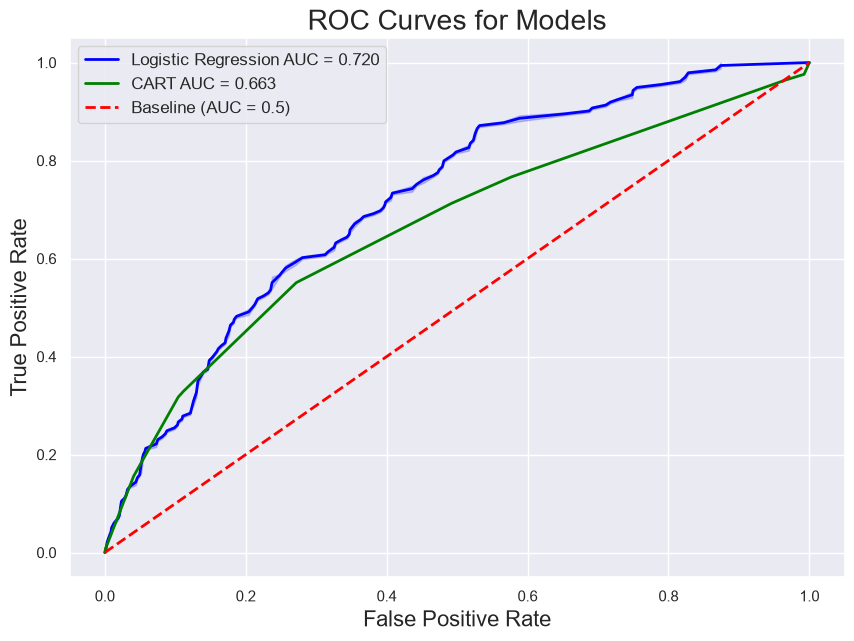

In [55]:
# Calculate ROC data
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_cart, tpr_cart, _ = roc_curve(y_test, cart_probs)
auc_cart = auc(fpr_cart, tpr_cart)

# Plot ROC
plt.figure(figsize=(10, 7))

# Logistic Regression Line
sns.lineplot(x=fpr_lr, y=tpr_lr, 
             label=f"Logistic Regression AUC = {auc_lr:.3f}", 
             color='blue', linewidth=2)

# CART Line
sns.lineplot(x=fpr_cart, y=tpr_cart, 
             label=f"CART AUC = {auc_cart:.3f}", 
             color='green', linewidth=2)

# Baseline Line
sns.lineplot(x=[0, 1], y=[0, 1], 
             label="Baseline (AUC = 0.5)", 
             color='red', linestyle="--", linewidth=2)

plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.title("ROC Curves for Models", fontsize=20)
plt.legend(fontsize=12)
plt.show()

**Question 6.** : Comment on ROC curves and the AUC values above. Overall, which model (logistic regression or CART) would you think is more useful to a doctor or medical practitioner?

**Answer 6.** In this example, the ROC curve for logistic regression is better (higher AUC) compared to CART. Logistic regression will be more useful in this example.

In [56]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

# Set consistent styling for plots
sns.set_theme(style="whitegrid")

# Problem 2: Random Forest and Boosting

In this problem, we will look at a more comprehensive version of the
Ames, Iowa Housing Prices dataset. Recall that the dataset describes
sales of 2,830 properties in the town of Ames, Iowa, from 2006 to 2010.
In Homework 2, we modeled housing prices using 11 independent variables.
The expanded dataset in this assignment contains 23 variables, some of
which are numerical and others are categorical.

The variables included in the amended dataset are described in **Table
2**. These variables describe the nature of the home in both
quantitative terms (square feet, lot size, number of rooms, etc.) and
qualitative terms (building materials used, garage type, home style,
etc.).

#### Table 2: Ames dataset variables

| Variable     | Description                                            |
|--------------|--------------------------------------------------------|
| LotArea      | Lot size in square feet                                |
| BldgType     | Type of dwelling                                       |
| HouseStyle   | Style of dwelling                                      |
| YearBuilt    | Original construction date                             |
| YearRemodAdd | Remodel date                   _                     |
| RoofStyle    | Type of roof                                           |
| BsmtFinSF1   | Type 1 finished square feet                            |
| BsmtUnfSF    | Unfinished square feet of basement area                |
| Electrical   | Electrical system                                      |
| GrLivArea    | Above ground living area square feet                   |
| FullBath     | Full bathrooms above grade         _                   |
| HalfBath     | Half baths above grade                                 |
| BedroomAbvGr | Number of bedrooms above basement level                |
| TotRmsAbvGrd | Total rooms above grade (excluding bathrooms)          |
| Fireplaces   | Number of fireplaces                                   |
| GarageYrBlt  | Year garage was built                 nbsp;                 |
| GarageCars   | Size of garage in car capacity               nbsp;         |
| GarageArea   | Size of garage in square feet                          |
| WoodDeckSF   | Wood deck area in square feet                          |
| OpenPorchSF  | Open porch area in square feet                         |
| PoolArea     | Pool area in square feet                               |
| YrSold       | Year Sold                                              |
| SalePrice    | The property’s sale price in dollars (target variable) |

Let's load our datasets, perform the usual train/test split, and define
the functions `calculate_osr2` for use later.

In [57]:
# Define a seed for reproducibility
R_STATE = 144

# Load the dataset
ames = pd.read_csv('AmesExtended.csv')

# --- Preprocessing ---
# Models require all data to be numeric. We'll one-hot encode categorical variables.
# We will use get_dummies, which handles 'object' or 'category' dtypes.
# drop_first=True helps reduce multicollinearity.
ames_processed = pd.get_dummies(ames, drop_first=True)

# Separate features (X) and target (y)
X = ames_processed.drop('SalePrice', axis=1)
y = ames_processed['SalePrice']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=R_STATE)

# Define the custom OSR2 function
def calculate_osr2(y_true, y_pred, y_train):
    """
    Calculates the Out-of-Sample R-squared (OSR2)
    using the training set's mean as the baseline.
    """
    sse = np.sum((y_true - y_pred)**2)
    sst_baseline = np.sum((y_true - y_train.mean())**2)
    
    # Handle potential division by zero
    if sst_baseline == 0:
        return np.nan
        
    return 1 - (sse / sst_baseline)

# Display the first few rows of the training data
print(X_train.head())
print(y_train.head())

      LotArea  YearBuilt  YearRemodAdd  BsmtFinSF1  BsmtUnfSF  GrLivArea  \
1969     4800       1916          1990         197        999       1196   
103     13517       1976          2005         533        192       1479   
1358    45600       1908          1997           0        907       2358   
196      8094       1915          1950           0        888       1962   
320      1491       1972          1972         150          0        630   

      FullBath  HalfBath  BedroomAbvGr  TotRmsAbvGrd  ...  HouseStyle_SLvl  \
1969         1         0             2             5  ...            False   
103          2         1             3             6  ...            False   
1358         3         0             5            10  ...            False   
196          1         1             4             9  ...            False   
320          1         0             1             3  ...            False   

      RoofStyle_Gable  RoofStyle_Gambrel  RoofStyle_Hip  RoofStyle_Mansard

In this problem, we will build a large variety of models. We'll use the
dataframe `results` to keep track of our model's performance.

In [58]:
# Initialize the results DataFrame
results = pd.DataFrame(
    data={
        'model_name': ['Linear Regression', 'CART with CV', 'Random Forest (Default)', 'Random Forest with CV', 'Boosting (Default)', 'Boosting with CV'],
        'r2': [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
        'osr2': [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
    }
)

results

,model_name,r2,osr2
0,Linear Regression,NaN,NaN
1,CART with CV,NaN,NaN
2,Random Forest (Default),NaN,NaN
3,Random Forest with CV,NaN,NaN
4,Boosting (Default),NaN,NaN
5,Boosting with CV,NaN,NaN


## (a) Linear Regression

Let's start with linear regression. Build a simple linear regression
model and print out a summary of the model.

In [59]:
# Define helper functions for printing stars
def significance_stars(p):
    """Returns the corresponding significance star string based on the p-value."""
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    """
    Prints a customized summary table from statsmodels OLS results
    including a column for significance stars.
    """
    # Use summary2 to get a DataFrame representation of the results table
    summary_table = model.summary2().tables[1]
    
    # Create the significance column
    summary_table['Signif'] = summary_table['P>|t|'].apply(significance_stars)

    # Round all numeric columns to 4 decimal places for clean printing
    rounded_table = summary_table.round(4)

    # Get the string representation of the table with header
    table_string = rounded_table.to_string(header=True)

    # Split the string into lines for formatting
    lines = table_string.split('\n')

    # Print the formatted table
    print("=" * len(lines[0]))
    print(lines[0])
    print("-" * len(lines[0]))
    print('\n'.join(lines[1:]))
    print("=" * len(lines[0]))
    print(f"R-squared: {model.rsquared:.4f}")

In [60]:
# --- (a) Linear Regression ---

# We use statsmodels to get a detailed summary
# We must add a constant (intercept) to the X data for statsmodels
X_train_sm = sm.add_constant(X_train)

# Fit the OLS (Ordinary Least Squares) model
lin_reg = sm.OLS(y_train, X_train_sm).fit()

# Print the summary
print_summary_with_stars(lin_reg)

# Prepare the test data (add constant) for later prediction
# We align the columns to ensure they match the training data,
# which handles any potential missing dummy variables (though unlikely here)
X_test_sm = sm.add_constant(X_test, has_constant='add')
X_test_sm = X_test_sm.reindex(columns=X_train_sm.columns, fill_value=0)

                         Coef.      Std.Err.        t   P>|t|        [0.025        0.975] Signif
------------------------------------------------------------------------------------------------
const             -148172.9460  1.117912e+06  -0.1325  0.8946 -2.340607e+06  2.044261e+06       
LotArea                 0.1593  1.005000e-01   1.5856  0.1130 -3.770000e-02  3.563000e-01       
YearBuilt             543.5681  4.285700e+01  12.6833  0.0000  4.595176e+02  6.276187e+02    ***
YearRemodAdd          464.6349  4.877950e+01   9.5252  0.0000  3.689692e+02  5.603006e+02    ***
BsmtFinSF1             20.2208  2.622200e+00   7.7115  0.0000  1.507820e+01  2.536340e+01    ***
BsmtUnfSF               8.2272  2.566200e+00   3.2059  0.0014  3.194300e+00  1.326000e+01     **
GrLivArea              65.1395  3.786700e+00  17.2021  0.0000  5.771310e+01  7.256600e+01    ***
FullBath             1213.8830  2.182169e+03   0.5563  0.5781 -3.065758e+03  5.493524e+03       
HalfBath            -1159.3308

Use the code below to calculate the In-Sample R2 and out-of-sample R2,
then append them onto `results`.

In [61]:
# Make predictions using the statsmodels model
y_pred_train_lr = lin_reg.predict(X_train_sm)
y_pred_test_lr = lin_reg.predict(X_test_sm)

# Calculate R2 and OSR2
# We can get the in-sample R2 directly from the model's attributes
r2_lr = lin_reg.rsquared
osr2_lr = calculate_osr2(y_test, y_pred_test_lr, y_train)

# Add to results
results.loc[0, 'r2'] = r2_lr
results.loc[0, 'osr2'] = osr2_lr

results

,model_name,r2,osr2
0,Linear Regression,0.794594,0.779092
1,CART with CV,NaN,NaN
2,Random Forest (Default),NaN,NaN
3,Random Forest with CV,NaN,NaN
4,Boosting (Default),NaN,NaN
5,Boosting with CV,NaN,NaN


------------------------------------------------------------------------

**Question 1.** : According to the linear regression model, what are
some variables that affect a property's sale price?

**Answer 1.**: The linear regression output indicates that key
predictors include: - YearBuilt - YearRemodAdd - BsmtFinSF1 -
BsmtUnfSF - GrLivArea - BedroomAbvGr - Fireplaces - GarageYrBlt -
GarageCars - PoolArea - WoodDeckSF - BldgType

## (b) CART

Use 10-fold cross validation to find a CART model that has the optimal `ccp_alpha` value. Test out `ccp_alpha` values from 0 to $10^8$ in increments of $10^7$, i.e. `np.arange(0, 1e8, 1e7)`.

In [62]:
# Define the parameter grid
# np.arange is exclusive of the stop value
param_grid_cart = {
    'ccp_alpha': np.arange(0, 1e8, 1e7)
}

# Initialize the GridSearchCV object
cart_cv = GridSearchCV(
    estimator=DecisionTreeRegressor(),
    param_grid=param_grid_cart,
    cv=10,
    scoring='r2'
)

# Fit the model
cart_cv.fit(X_train, y_train)

# Display results
cart_cv_results = pd.DataFrame(cart_cv.cv_results_)
print(cart_cv_results[['param_ccp_alpha', 'mean_test_score', 'std_test_score']])

# Display the best parameter
print("\nBest ccp_alpha:", cart_cv.best_params_)

   param_ccp_alpha  mean_test_score  std_test_score
0              0.0         0.701779        0.066367
1       10000000.0         0.770314        0.037174
2       20000000.0         0.737053        0.029902
3       30000000.0         0.714883        0.032132
4       40000000.0         0.706659        0.035363
5       50000000.0         0.698135        0.039927
6       60000000.0         0.688982        0.041323
7       70000000.0         0.679008        0.033394
8       80000000.0         0.673907        0.035510
9       90000000.0         0.671478        0.033082

Best ccp_alpha: {'ccp_alpha': np.float64(10000000.0)}


Using the optimal cross-validated `ccp_alpha` value, train a CART model called
`cart_best`. Let's add its performance to our dataframe `results`.

In [63]:
# Get the best model from the grid search
# GridSearchCV automatically re-fits the best model on the entire training set
cart_best = cart_cv.best_estimator_

# Make predictions
y_pred_train_cart = cart_best.predict(X_train)
y_pred_test_cart = cart_best.predict(X_test)

# Calculate R2 and OSR2
r2_cart = r2_score(y_train, y_pred_train_cart)
osr2_cart = calculate_osr2(y_test, y_pred_test_cart, y_train)

# Add to results
results.loc[1, 'r2'] = r2_cart
results.loc[1, 'osr2'] = osr2_cart

results

,model_name,r2,osr2
0,Linear Regression,0.794594,0.779092
1,CART with CV,0.856209,0.783814
2,Random Forest (Default),NaN,NaN
3,Random Forest with CV,NaN,NaN
4,Boosting (Default),NaN,NaN
5,Boosting with CV,NaN,NaN


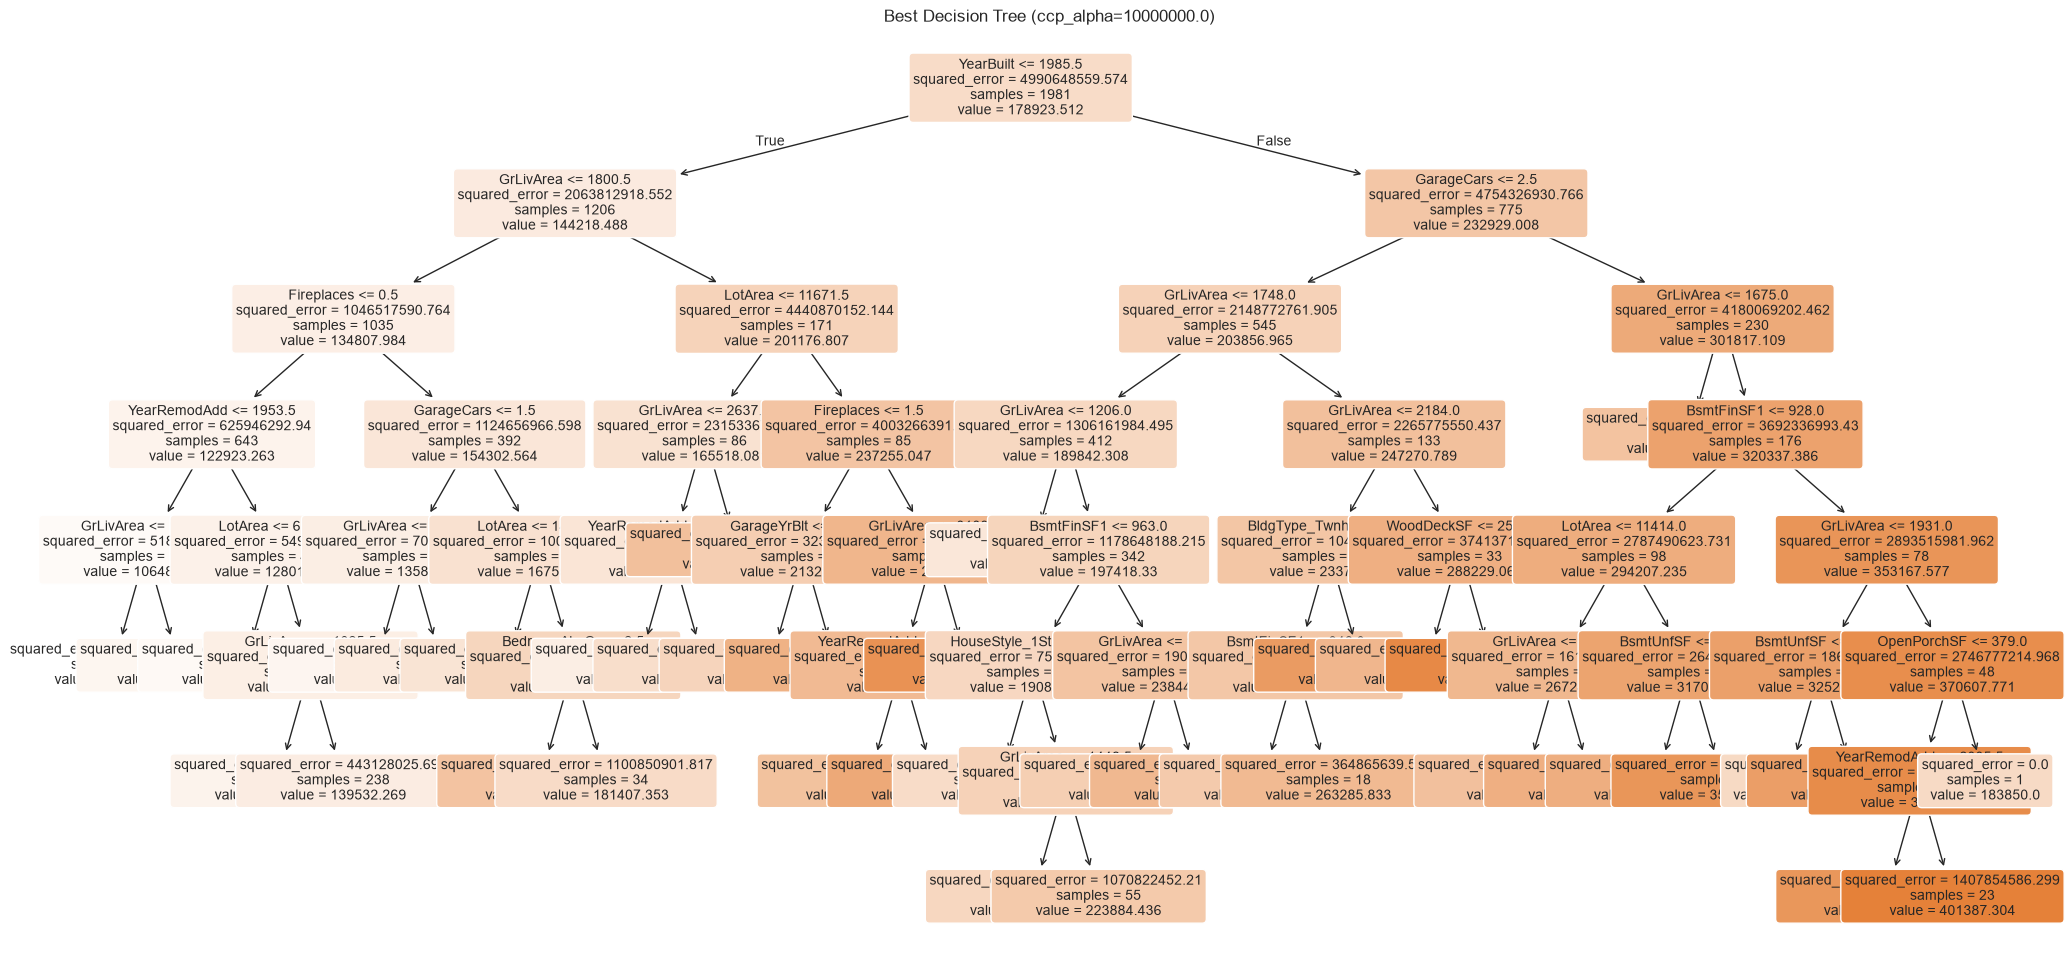

In [64]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Get the best model from the grid search
best_tree = cart_cv.best_estimator_

# 2. Set up a large figure (trees can be wide)
plt.figure(figsize=(25, 12))

# 3. Plot the tree
plot_tree(
    best_tree,
    feature_names=list(X_train.columns),  # Use this if X_train is a DataFrame
    filled=True,                    # Colors nodes based on predicted value
    rounded=True,                   # Rounds the corners of the nodes
    fontsize=10
)

plt.title(f"Best Decision Tree (ccp_alpha={cart_cv.best_params_['ccp_alpha']})")
plt.show()

## (c) Random Forest

Now, let's try a random forest model.

### Default Values

First, let's train a model with its default parameters and no cross
validation for parameter tuning.

In [65]:
# Initialize and fit the default Random Forest model
rf_model = RandomForestRegressor(random_state=R_STATE)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

# Calculate R2 and OSR2
r2_rf = r2_score(y_train, y_pred_train_rf)
osr2_rf = calculate_osr2(y_test, y_pred_test_rf, y_train)

# Add to results
results.loc[2, 'r2'] = r2_rf
results.loc[2, 'osr2'] = osr2_rf

results

,model_name,r2,osr2
0,Linear Regression,0.794594,0.779092
1,CART with CV,0.856209,0.783814
2,Random Forest (Default),0.981833,0.865761
3,Random Forest with CV,NaN,NaN
4,Boosting (Default),NaN,NaN
5,Boosting with CV,NaN,NaN


### Cross Validation

Now, let's run cross validation to find the best value of `max_features`. Use 5-fold cross validation to find the best value out of the numbers from 1 to 16 in increments of 3. Let's set the number of trees to be 100, to reduce the run-time.

In [66]:
# Define the parameter grid
# We use 
# 6 values: 1, 4, 7, 10, 13, 16
param_grid_rf = {
    'max_features': [1,4,7, 10, 13, 16]
}

# Initialize the GridSearchCV object
rf_cv = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=100, random_state=R_STATE),
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2'
)

# Fit the model
rf_cv.fit(X_train, y_train)

# Display results
rf_cv_results = pd.DataFrame(rf_cv.cv_results_)
print(rf_cv_results[['param_max_features', 'mean_test_score', 'std_test_score']])

   param_max_features  mean_test_score  std_test_score
0                   1         0.832135        0.009186
1                   4         0.851301        0.009445
2                   7         0.857723        0.009821
3                  10         0.861545        0.011618
4                  13         0.864786        0.008867
5                  16         0.862863        0.011307


------------------------------------------------------------------------

**Question 2.** In the code above, what is the total number of CART
models that are fit? Show your work.

**Answer 2.** 6 * 5 * 100 = 3000 trees.

Let's take a look at how the value of `max_features` affects our cross-validated $R^2$.

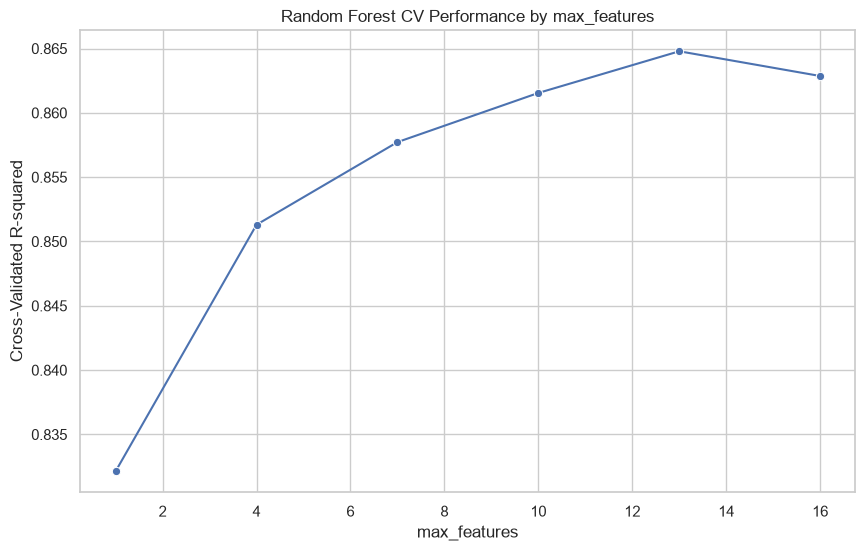

In [67]:
# Plot the results
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=rf_cv_results,
    x='param_max_features',
    y='mean_test_score',
    marker='o'
)
plt.xlabel('max_features')
plt.ylabel('Cross-Validated R-squared')
plt.title('Random Forest CV Performance by max_features')
plt.show()

------------------------------------------------------------------------

**Question 3.**. Why is it important to tune `max_features`? (i.e., what happens
if you set it too high or too low?)

**Answer 3.** `max_features` is the number of variables randomly sampled as
candidates at each split. Tuning `max_features` is crucial because a value set too
high reduces tree diversity (increasing overfitting), whereas too low a
value may ignore important predictors.

Let's take this optimal value of `max_features` and create a final Random Forest
model using it. Compute its performance and add it to the dataframe
`results`.

In [68]:
# Get the best model from the grid search
rf_best = rf_cv.best_estimator_

# Make predictions
y_pred_train_rf_best = rf_best.predict(X_train)
y_pred_test_rf_best = rf_best.predict(X_test)

# Calculate R2 and OSR2
r2_rf_best = r2_score(y_train, y_pred_train_rf_best)
osr2_rf_best = calculate_osr2(y_test, y_pred_test_rf_best, y_train)

# Add to results
results.loc[3, 'r2'] = r2_rf_best
results.loc[3, 'osr2'] = osr2_rf_best

results

,model_name,r2,osr2
0,Linear Regression,0.794594,0.779092
1,CART with CV,0.856209,0.783814
2,Random Forest (Default),0.981833,0.865761
3,Random Forest with CV,0.981358,0.865637
4,Boosting (Default),NaN,NaN
5,Boosting with CV,NaN,NaN


Finally, let's examine the feature importance from this model `rf_best`.
Run the following code to generate this graph.

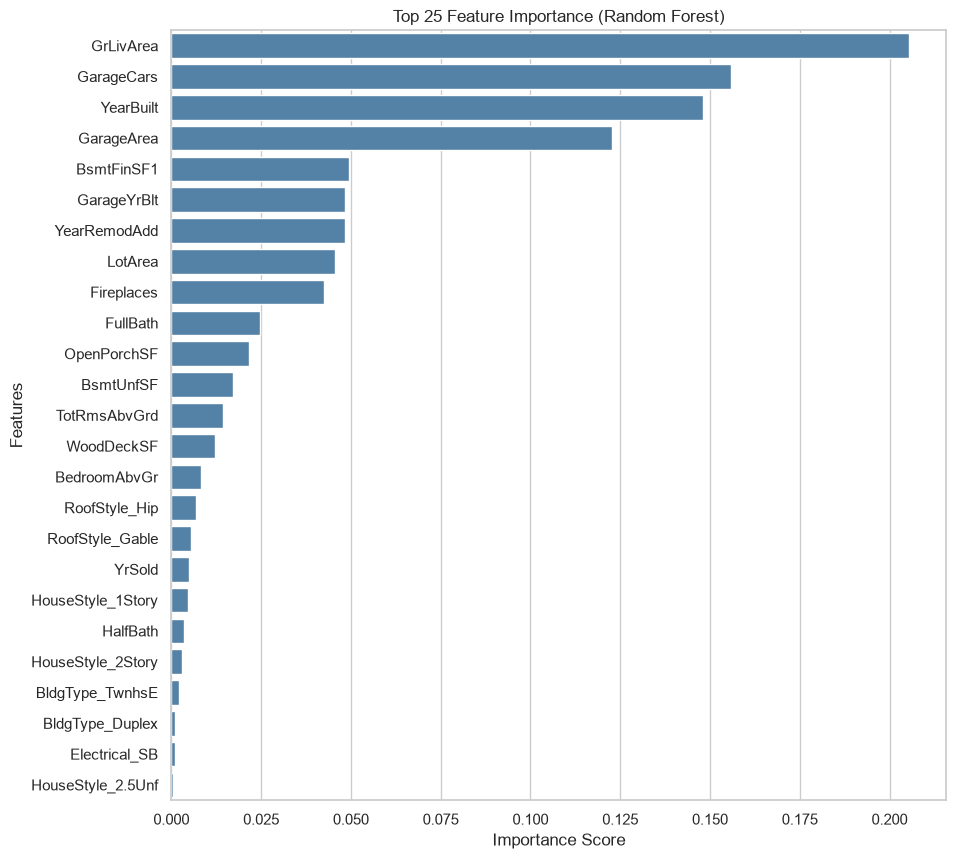

In [69]:
# Get feature importances
importances = rf_best.feature_importances_
features = X_train.columns

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 25 features
plt.figure(figsize=(10, 10))
sns.barplot(
    data=importance_df.head(25),
    x='Importance',
    y='Feature',
    color='steelblue'
)
plt.title('Top 25 Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

**Question 4.** Compare the important features from random forest with
the significant variables from Linear Regression. Do they roughly match?

**Answer 4.** They do roughly match. Thus, we see that once again, the
following features seem important: - YearBuilt - GrLivArea -
GarageCars - GarageArea - GarageYrBIt - BsmtFinSF1 - Fireplaces - LotArea
YearRemodAdd

## (d) Boosting

Finally, let's use boosted trees.

### Default Parameters

Again, we start with the default parameters. Train this model and add its performance metrics to
`results`.

In [70]:
# Initialize and fit the default Gradient Boosting model
boosted_tree = GradientBoostingRegressor(random_state=R_STATE)
boosted_tree.fit(X_train, y_train)

# Make predictions
y_pred_train_boost = boosted_tree.predict(X_train)
y_pred_test_boost = boosted_tree.predict(X_test)

# Calculate R2 and OSR2
r2_boost = r2_score(y_train, y_pred_train_boost)
osr2_boost = calculate_osr2(y_test, y_pred_test_boost, y_train)

# Add to results
results.loc[4, 'r2'] = r2_boost
results.loc[4, 'osr2'] = osr2_boost

results

,model_name,r2,osr2
0,Linear Regression,0.794594,0.779092
1,CART with CV,0.856209,0.783814
2,Random Forest (Default),0.981833,0.865761
3,Random Forest with CV,0.981358,0.865637
4,Boosting (Default),0.929773,0.866001
5,Boosting with CV,NaN,NaN


### Cross Validation

Now let's do some parameter tuning using cross validation. Let's keep `learning_rate` and `min_samples_leaf` at their default values of 0.1 and 10 respectively. Let's search over `n_estimators` in [100, 500, 1000, 3000] and
`max_depth` in [1, 3, 5, 7, 9]. To save computation time, let's just run 3-fold cross validation.

In [71]:
# Define the parameter grid
param_grid_gbm = {
    'n_estimators': [100, 500, 1000, 3000],
    'max_depth': [1, 3, 5, 7, 9]
}

# Initialize the base estimator with the specified non-default parameters
gbm_base_estimator = GradientBoostingRegressor(
    learning_rate=0.1,
    min_samples_leaf=10,
    random_state=R_STATE
)

# Initialize the GridSearchCV object
gbm_cv = GridSearchCV(
    estimator=gbm_base_estimator,
    param_grid=param_grid_gbm,
    cv=3,
    scoring='r2',
    verbose=0
)

# Fit the model (this may take a few minutes)
gbm_cv.fit(X_train, y_train)

# Display results
gbm_cv_results = pd.DataFrame(gbm_cv.cv_results_)
print(gbm_cv_results[['param_max_depth', 'param_n_estimators', 'mean_test_score']])

    param_max_depth  param_n_estimators  mean_test_score
0                 1                 100         0.813387
1                 1                 500         0.830962
2                 1                1000         0.833490
3                 1                3000         0.834290
4                 3                 100         0.847373
5                 3                 500         0.847895
6                 3                1000         0.843415
7                 3                3000         0.838535
8                 5                 100         0.854041
9                 5                 500         0.848797
10                5                1000         0.847392
11                5                3000         0.847104
12                7                 100         0.851661
13                7                 500         0.847718
14                7                1000         0.847403
15                7                3000         0.847377
16                9            

------------------------------------------------------------------------

**Question 5.** In running this cross validation over the parameter
grid, how many CART models did we build in total?

**Answer 5.** (100 + 500 + 1000 + 3000) * 5 * 3 = 69000.

Let's see how the various parameters performed by plotting a heat map of $R^2$.

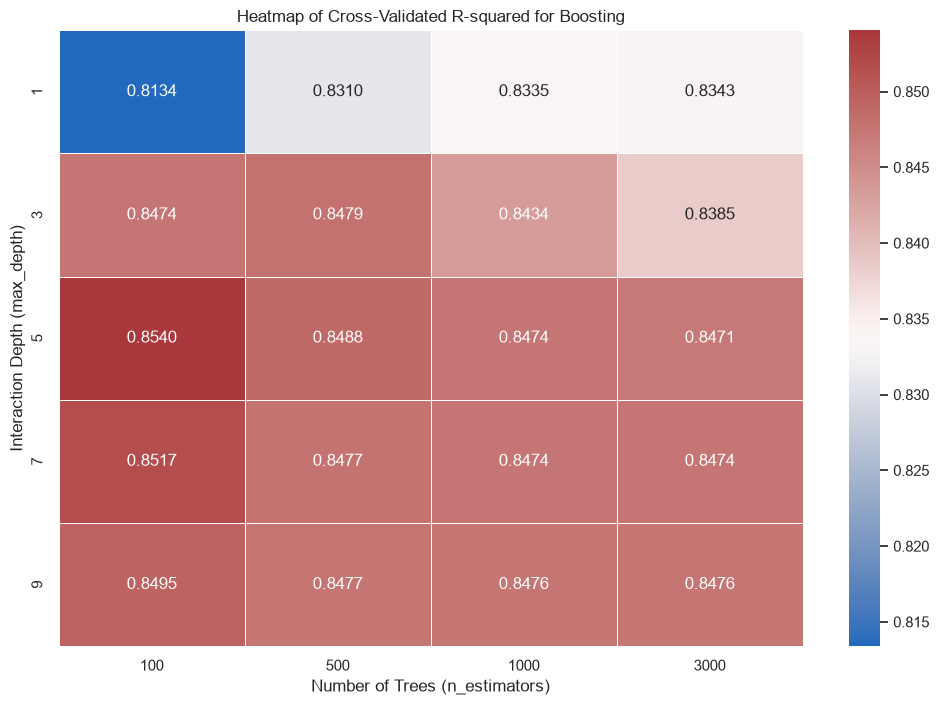

In [72]:
# Pivot the results for the heatmap
heatmap_data = gbm_cv_results.pivot(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score'
)

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="vlag", # Use a diverging colormap
    linewidths=.5
)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Interaction Depth (max_depth)')
plt.title('Heatmap of Cross-Validated R-squared for Boosting')
plt.show()

------------------------------------------------------------------------

**Question 6.** Discuss the impact of `max_depth` and `n_estimators` on the cross-validated R2. Are there any signs of overfitting or underfitting?

**Answer 6.** `max_depth` limits how many levels of interactions
each tree can capture: higher values allow more complexity but risk
overfitting. `n_estimators` sets the total number of trees in the ensemble.
Increasing `n_estimators` and `max_depth` boosts $R^2$ until reaching an
optimal point; beyond that, too many trees or excessive depth may lower
the cross-validated $R^2$, indicating overfitting. Conversely, too-low
settings can lead to underfitting. Here, for the smallest values of
`n_estimators` in particular `max_depth`, we see poor performance:
this is underfitting. As we increase these parameters, the performance
improve up to a certain point and then decrease again. Thus, the
performance obtained for the largest values of `n_estimators` and
`max_depth` is suboptimal: we are overfitting. Some intermediate
values of `n_estimators` and `max_depth` seem to give the best
results.

Let's see what the best parameters was.

In [73]:
print(gbm_cv.best_params_)

{'max_depth': 5, 'n_estimators': 100}


Train a model with the best parameter values and add its R2/OSR2 to our
results dataframe.

In [74]:
# Get the best model from the grid search
opt_boost = gbm_cv.best_estimator_

# Make predictions
y_pred_train_boost_best = opt_boost.predict(X_train)
y_pred_test_boost_best = opt_boost.predict(X_test)

# Calculate R2 and OSR2
r2_boost_best = r2_score(y_train, y_pred_train_boost_best)
osr2_boost_best = calculate_osr2(y_test, y_pred_test_boost_best, y_train)

# Add to results
results.loc[5, 'r2'] = r2_boost_best
results.loc[5, 'osr2'] = osr2_boost_best

results

,model_name,r2,osr2
0,Linear Regression,0.794594,0.779092
1,CART with CV,0.856209,0.783814
2,Random Forest (Default),0.981833,0.865761
3,Random Forest with CV,0.981358,0.865637
4,Boosting (Default),0.929773,0.866001
5,Boosting with CV,0.960873,0.877102


## (e) Model Comparison and Discussion

Great work! We now have the performance for 6 different models. Let's
discuss the results.

In [75]:
# Set model_name as index for better readability
results.set_index('model_name', inplace=True)
print(results.round(4))

                             r2    osr2
model_name                             
Linear Regression        0.7946  0.7791
CART with CV             0.8562  0.7838
Random Forest (Default)  0.9818  0.8658
Random Forest with CV    0.9814  0.8656
Boosting (Default)       0.9298  0.8660
Boosting with CV         0.9609  0.8771


**Question 7.** Comment on the performance of all 6 models. In
particular please address:

1.  The value of ensemble learning

2.  The value of parameter tuning

3.  Tradeoffs in terms of running time and interpretability.

**Answers 7.** General Comments Here.

1.  Ensemble learning (e.g. combining many trees) generally boosts
    accuracy (often) by averaging out individual model errors.

2.  Parameter tuning can substantially improve performance by
    identifying optimal hyperparameters.

3.  However, more complex (ensemble) models tend to run slower and are
    less interpretable than simpler ones.

------------------------------------------------------------------------

**Question 8.** For each of the following use-cases, please say which
model (in rows 1-6) would be the best choice. Justify your answers.

1.  You are a property developer who refurbishes properties through new construction and upgrades to maximize the resale value. You want a model where you can easily tell whether, for example, adding an extra fireplace or adding an extra bathroom will be more impactful to a property's predicted value. What model would you choose?
2.  You are testifying in court in a litigation case involving unfair housing prices in the real estate market, and you will need to defend your methodology if asked. You need to explain exactly how your model made its predictions to a lay audience of jurors. To ensure you can provide satisfactory reasoning, what model would you use to determine housing prices?
3.  You utilize data-driven models to estimate property values for a real-estate firm, advising your clients on asking prices and bidding price strategies to maximize their gain. You must provide daily updates to your clients using new price data that comes in on a daily basis, so your model cannot take too long to run. Which model would you use to help inform your recommendations?

**Answers 8.**

1.  If you need to see the impact of adding a feature (e.g. an extra fireplace), choose the **linear regression** model because its coefficients (from the `statsmodels` summary) are directly interpretable.
2.  When testifying in court, the **linear regression** model is ideal since its straightforward, transparent relationships can be clearly explained.
3.  Since the updates need to happen daily, the model needs to be relatively fast to train but it can take a few minutes or hours. Thus, **Boosted Trees** with CV would be the best option given its high performance. If speed is essential, Linear Regression, CART, Random Forest with default parameters or Boosted Trees with default parameters would be advised. Here Boosting with CV has the best performance so would be the model to use.